# Lab 5: Fuzzy Inference Systems

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import skfuzzy as fuzz
plt.rcParams['figure.figsize'] = [10, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## Part A: Mamdani Inference from Scratch

### Step 1: Define Membership Functions

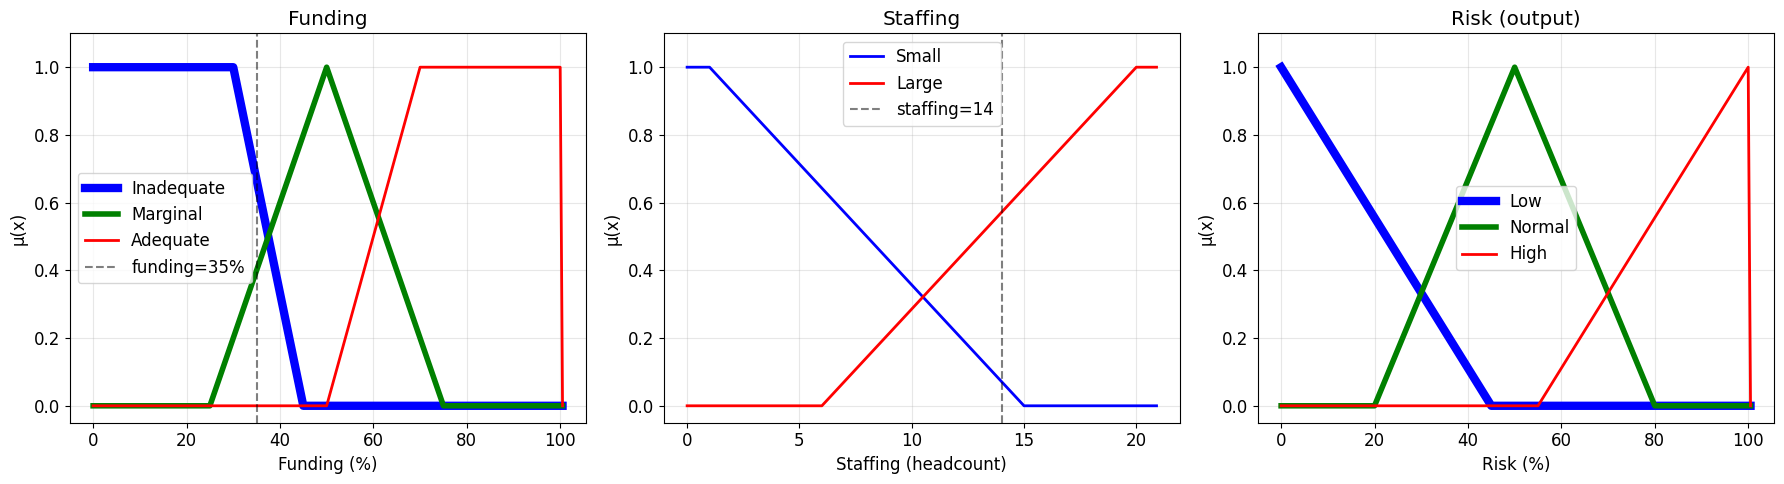

In [2]:
# Universes of discourse
x_fund = np.arange(0, 101, 0.5)
x_staff = np.arange(0, 21, 0.1)
x_risk = np.arange(0, 101, 0.5)

# --- Funding MFs ---
# Inadequate: (0,1)→(30,1)→(45,0) — trapezoidal left-shoulder
fund_inadequate = fuzz.trapmf(x_fund, [0, 0, 30, 45])

# Marginal: triangle (25, 50, 75)
# TODO: create the "marginal" fuzzy set here
# Tip: use skfuzzy's "trimf" function
fund_marginal = fuzz.trimf(x_fund, [25, 50, 75])

# Adequate: (50,0)→(70,1)→(100,1) — trapezoidal right-shoulder
# TODO: create the "adequate" fuzzy set here
fund_adequate = fuzz.trapmf(x_fund, [50, 70, 100, 100])

# --- Staffing MFs ---
# Small: (1,1)→(15,0) left-shoulder trapezoid
# TODO: create the "small" fuzzy set here
staff_small = fuzz.trapmf(x_staff, [0, 0, 1, 15])

# Large: (6,0)→(20,1) right-shoulder trapezoid
# TODO: create the "large" fuzzy set here
staff_large = fuzz.trapmf(x_staff, [6, 20, 21, 21])

# --- Risk MFs ---
# Low: (0,1)→(45,0) left-shoulder trapezoid
# TODO: create the "low" fuzzy set here
risk_low = fuzz.trapmf(x_risk, [0, 0, 0, 45])

# Normal: triangle (20, 50, 80)
# TODO: create the "normal" fuzzy set here
risk_normal = fuzz.trimf(x_risk, [20, 50, 80])

# High: (55,0)→(100,1) right-shoulder trapezoid
# TODO: create the "high" fuzzy set here
risk_high = fuzz.trapmf(x_risk, [55, 100, 100, 100])

# --- Plot ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(x_fund, fund_inadequate, 'b-', lw=6, label='Inadequate')
ax1.plot(x_fund, fund_marginal, 'g-', lw=4, label='Marginal')
ax1.plot(x_fund, fund_adequate, 'r-', lw=2, label='Adequate')
ax1.axvline(x=35, color='k', ls='--', alpha=0.5, label='funding=35%')
ax1.set_title('Funding')
ax1.set_xlabel('Funding (%)')
ax1.set_ylabel('μ(x)')
ax1.legend()

ax2.plot(x_staff, staff_small, 'b-', lw=2, label='Small')
ax2.plot(x_staff, staff_large, 'r-', lw=2, label='Large')
ax2.axvline(x=14, color='k', ls='--', alpha=0.5, label='staffing=14')
ax2.set_title('Staffing')
ax2.set_xlabel('Staffing (headcount)')
ax2.set_ylabel('μ(x)')
ax2.legend()

ax3.plot(x_risk, risk_low, 'b-', lw=6, label='Low')
ax3.plot(x_risk, risk_normal, 'g-', lw=4, label='Normal')
ax3.plot(x_risk, risk_high, 'r-', lw=2, label='High')
ax3.set_title('Risk (output)')
ax3.set_xlabel('Risk (%)')
ax3.set_ylabel('μ(x)')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Step 2: Fuzzification

In [3]:
# Crisp inputs
funding_val = 35
staffing_val = 14

# Fuzzify funding
# Calculate the degree of membership (DoM) for "inadequate"
mu_inadequate = fuzz.interp_membership(x_fund, fund_inadequate, funding_val)
# TODO: Calculate DoM for "marginal" here
mu_marginal = fuzz.interp_membership(x_fund, fund_marginal, funding_val)
# TODO: Calculate DoM for "adequate" here
mu_adequate = fuzz.interp_membership(x_fund, fund_adequate, funding_val)

# Fuzzify staffing
# TODO: Calculate DoM for "small" here
mu_small = fuzz.interp_membership(x_staff, staff_small, staffing_val)
# TODO: Calculate DoM for "large" here
mu_large = fuzz.interp_membership(x_staff, staff_large, staffing_val)

print(f"Fuzzification: funding = {funding_val}%, staffing = {staffing_val}")
print(f"{'─' * 45}")
print(f" μ_inadequate({funding_val}) = {mu_inadequate:.4f}")
print(f" μ_marginal({funding_val}) = {mu_marginal:.4f}")
print(f" μ_adequate({funding_val}) = {mu_adequate:.4f}")
print()
print(f" μ_small({staffing_val}) = {mu_small:.4f}")
print(f" μ_large({staffing_val}) = {mu_large:.4f}")

Fuzzification: funding = 35%, staffing = 14
─────────────────────────────────────────────
 μ_inadequate(35) = 0.6667
 μ_marginal(35) = 0.4000
 μ_adequate(35) = 0.0000

 μ_small(14) = 0.0714
 μ_large(14) = 0.5714


### Step 3: Rule Evaluation

Rule evaluation:
 Rule 1: max(adequate=0.000, small=0.071) = 0.071 → clip 'low'
 Rule 2: min(marginal=0.400, large=0.571) = 0.400 → clip 'normal'
 Rule 3: inadequate = 0.667 → clip 'high'


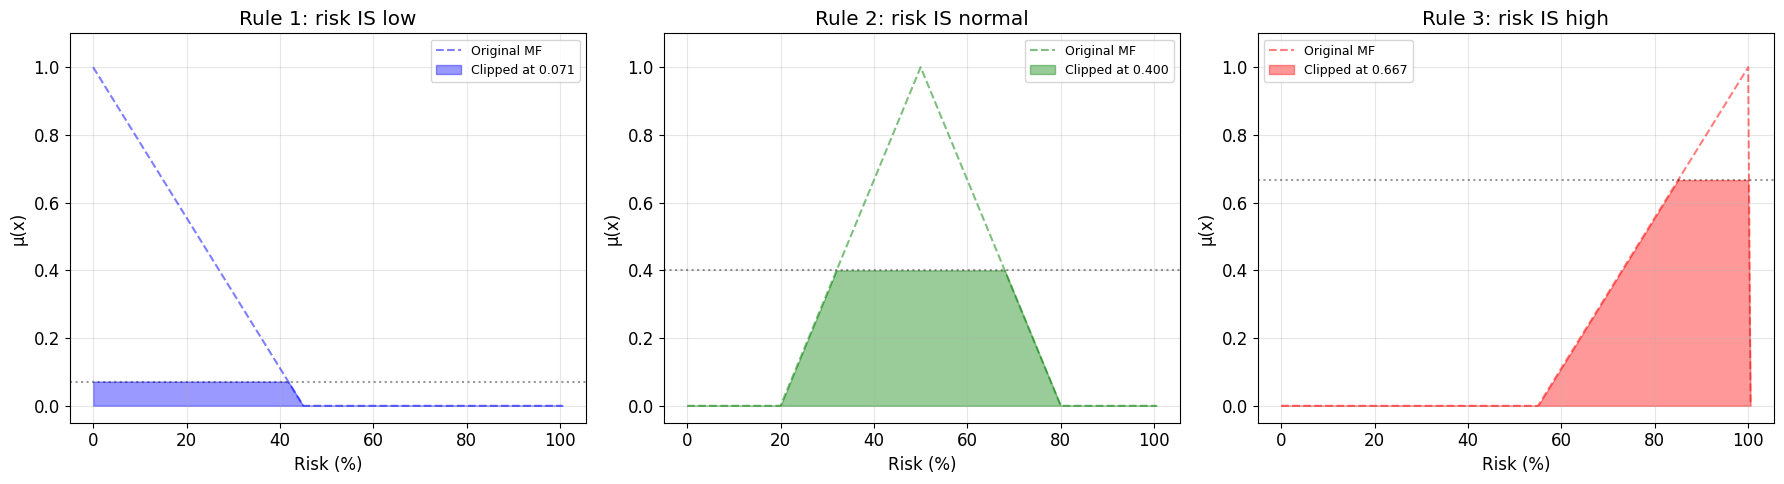

In [4]:
# Rule 1: IF funding IS adequate OR (max) staffing IS small THEN risk IS low
rule1_strength = max(mu_adequate, mu_small)
rule1_output = np.minimum(rule1_strength, risk_low) # Clip (min-implication)

# Rule 2: IF funding IS marginal AND (min) staffing IS large THEN risk IS normal
# TODO: Code Rule 2 here
rule2_strength = min(mu_marginal, mu_large)
rule2_output = np.minimum(rule2_strength, risk_normal) # Clip

# Rule 3: IF funding IS inadequate THEN risk IS high
rule3_strength = mu_inadequate
rule3_output = np.minimum(rule3_strength, risk_high) # Clip

print("Rule evaluation:")
print(f" Rule 1: max(adequate={mu_adequate:.3f}, small={mu_small:.3f}) " \
      f"= {rule1_strength:.3f} → clip 'low'")
print(f" Rule 2: min(marginal={mu_marginal:.3f}, large={mu_large:.3f}) " \
      f"= {rule2_strength:.3f} → clip 'normal'")
print(f" Rule 3: inadequate = {rule3_strength:.3f} → clip 'high'")

# Plot clipped consequents
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Rule 1: risk IS low', 'Rule 2: risk IS normal', 'Rule 3: risk IS high']
originals = [risk_low, risk_normal, risk_high]
clipped = [rule1_output, rule2_output, rule3_output]
strengths = [rule1_strength, rule2_strength, rule3_strength]
colors = ['blue', 'green', 'red']

for ax, title, orig, clip, strength, color in zip(axes, titles, originals,
                                                    clipped, strengths, colors):
    ax.plot(x_risk, orig, color=color, ls='--', lw=1.5, alpha=0.5, label='Original MF')
    ax.fill_between(x_risk, clip, alpha=0.4, color=color, label=f'Clipped at {strength:.3f}')
    ax.axhline(y=strength, color='k', ls=':', alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('Risk (%)')
    ax.set_ylabel('μ(x)')
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Step 4: Aggregation

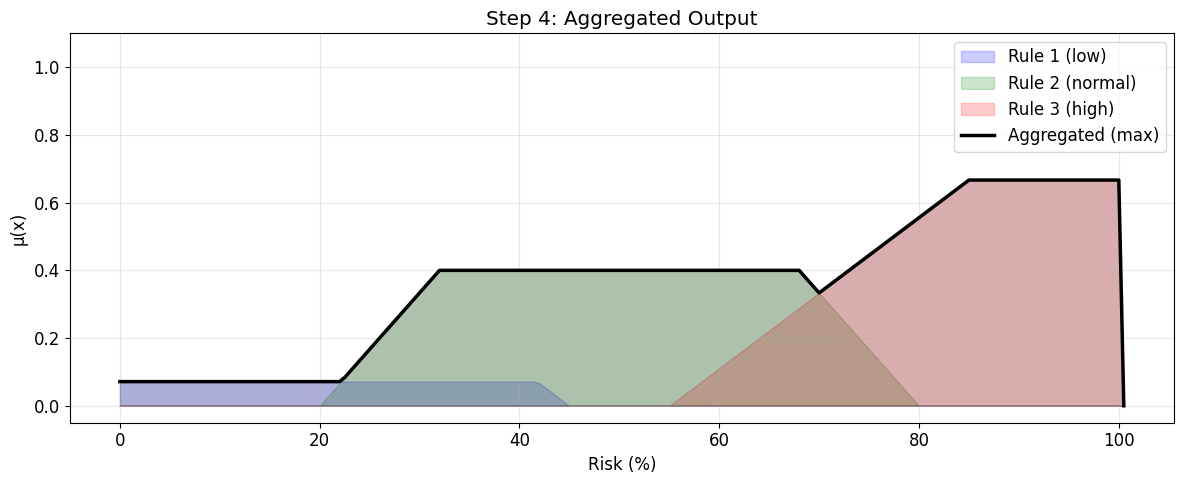

In [5]:
# Aggregate using max
# TODO: Calculate the "aggregated" result by using numpy's "maximum" function
# on the Rules 1, 2, and 3 outputs
aggregated = np.maximum(np.maximum(rule1_output, rule2_output), rule3_output)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, rule1_output, alpha=0.2, color='blue', label='Rule 1 (low)')
ax.fill_between(x_risk, rule2_output, alpha=0.2, color='green', label='Rule 2 (normal)')
ax.fill_between(x_risk, rule3_output, alpha=0.2, color='red', label='Rule 3 (high)')
ax.plot(x_risk, aggregated, 'k-', lw=2.5, label='Aggregated (max)')
ax.fill_between(x_risk, aggregated, alpha=0.15, color='black')
ax.set_title('Step 4: Aggregated Output')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.set_ylim(-0.05, 1.1)
ax.legend()
plt.tight_layout()
plt.show()

### Step 5: Defuzzification 

Defuzzification results (funding=35%, staffing=14):
 COG (Centre of Gravity): 64.89%
 MOM (Mean of Maxima): 92.50%
 SOM (Smallest of Maxima): 85.00%
 LOM (Largest of Maxima): 100.00%


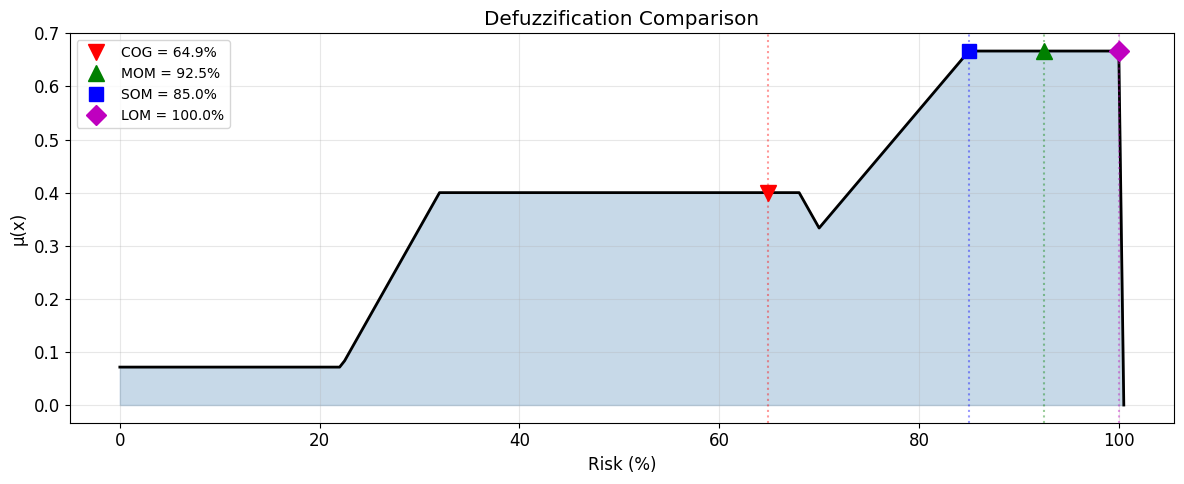

In [6]:
def defuzzify_cog(x, mf):
    """Centre of Gravity (centroid) defuzzification."""
    if np.sum(mf) == 0:
        return 0
    # TODO: Compute and return the COG result using the
    # numpy's "sum" function twice here
    # Tip: See the COG equation in the MD cell above,
    # where "z" there is the "x" attribute here
    return np.sum(mf * x) / np.sum(mf)

def defuzzify_mom(x, mf):
    """Mean of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return np.mean(x[max_indices])

def defuzzify_som(x, mf):
    """Smallest of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return x[max_indices[0]]

def defuzzify_lom(x, mf):
    """Largest of Maxima defuzzification."""
    max_val = np.max(mf)
    if max_val == 0:
        return 0
    max_indices = np.where(np.isclose(mf, max_val, atol=1e-6))[0]
    return x[max_indices[-1]]

# Compute all four
# Compute COG
cog = defuzzify_cog(x_risk, aggregated)
# TODO: Compute MOM
mom = defuzzify_mom(x_risk, aggregated)
# TODO: Compute SOM
som = defuzzify_som(x_risk, aggregated)
# TODO: Compute LOM
lom = defuzzify_lom(x_risk, aggregated)

print(f"Defuzzification results (funding={funding_val}%, staffing={staffing_val}):")
print(f" COG (Centre of Gravity): {cog:.2f}%")
print(f" MOM (Mean of Maxima): {mom:.2f}%")
print(f" SOM (Smallest of Maxima): {som:.2f}%")
print(f" LOM (Largest of Maxima): {lom:.2f}%")

# Plot with defuzzification points
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_risk, aggregated, alpha=0.3, color='steelblue')
ax.plot(x_risk, aggregated, 'k-', lw=2)

markers = {'COG': (cog, 'rv', 12), 'MOM': (mom, 'g^', 12),
           'SOM': (som, 'bs', 10), 'LOM': (lom, 'mD', 10)}

for name, (val, marker, ms) in markers.items():
    ax.plot(val, fuzz.interp_membership(x_risk, aggregated, val),
            marker, markersize=ms, label=f'{name} = {val:.1f}%')
    ax.axvline(x=val, color=marker[0], ls=':', alpha=0.4)

ax.set_title('Defuzzification Comparison')
ax.set_xlabel('Risk (%)')
ax.set_ylabel('μ(x)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Part B: Fuzzy Inference with pyfuzzylite

In [7]:
# pip install pyfuzzylite --no-deps
import fuzzylite as fl
from fuzzylite import settings
import warnings
# Suppress numpy deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
# Register custom hedges to match lecture slide definitions
settings.factory_manager.hedge.constructors["slightly"] = \
 lambda: fl.HedgeLambda("slightly", lambda x: x**1.7)
settings.factory_manager.hedge.constructors["a_little"] = \
 lambda: fl.HedgeLambda("a_little", lambda x: x**1.3)
#TODO: Register the custom "More or Less" hedge (x^0.5)
settings.factory_manager.hedge.constructors["more_or_less"] = \
 lambda: fl.HedgeLambda("more_or_less", lambda x: x**0.5)
# TODO: Override "Extremely" to match slides (x^3) instead of pyfuzzylite's default
settings.factory_manager.hedge.constructors["extremely"] = \
 lambda: fl.HedgeLambda("extremely", lambda x: x**3)
# Register additional hedges from the slides
settings.factory_manager.hedge.constructors["very_very"] = \
 lambda: fl.HedgeLambda("very_very", lambda x: x**4)
# Built-in hedges that already match slides: very (x^2), somewhat (x^(1/3)), not (1-x)
print("Registered hedges:", list(settings.factory_manager.hedge.constructors.keys()))

Registered hedges: ['any', 'extremely', 'not', 'seldom', 'somewhat', 'very', 'slightly', 'a_little', 'more_or_less', 'very_very']


### B.1: Mamdani with pyfuzzylite — Project Staffing

In [8]:
# Project staffing Mamdani system
staffing_engine = fl.Engine(
    name="ProjectStaffing",
    input_variables=[
        fl.InputVariable(
            name="funding", minimum=0.0, maximum=100.0,
            terms=[
                fl.Trapezoid("inadequate", 0, 0, 30, 45),
                # TODO: using pyfuzzylite's "Triangle" function,
                # define here the "Marginal" fuzzy set with
                # the same parameters as in Part A, Step 1
                fl.Triangle("marginal", 25, 50, 75),
                # TODO: using pyfuzzylite's "Trapezoid" function,
                # define here the "Adequate" fuzzy set with
                # the same parameters as in Part A, Step 1
                fl.Trapezoid("adequate", 50, 70, 100, 100),
            ]
        ),
        fl.InputVariable(
            name="staffing", minimum=1.0, maximum=20.0,
            terms=[
                fl.Ramp("small", 15, 1), # Descending: from 1(=1.0) to 15(=0.0)
                fl.Ramp("large", 6, 20), # Ascending: from 6(=0.0) to 20(=1.0)
            ]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="risk", minimum=0.0, maximum=100.0,
            aggregation=fl.Maximum(),
            defuzzifier=fl.Centroid(500),
            terms=[
                fl.Ramp("low", 45, 0), # Descending: from 0(=1.0) to 45(=0.0)
                # TODO: using pyfuzzylite's "Triangle" function,
                # define here the "Normal" fuzzy set with
                # the same parameters as in Part A, Step 1
                fl.Triangle("normal", 20, 50, 80),
                # TODO: using pyfuzzylite's "Ramp" function,
                # define here the "High" fuzzy set with
                # the same parameters as in Part A, Step 1
                # Ascending: from 55(=0.0) to 100(=1.0)
                fl.Ramp("high", 55, 100),
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(), # AND = min
            disjunction=fl.Maximum(), # OR = max
            implication=fl.Minimum(), # Clip (min-implication)
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if funding is adequate or staffing is small "
                     "then risk is low")
                ),
                fl.Rule.create(
                    ("if funding is marginal and staffing is large "
                     "then risk is normal")
                ),
                fl.Rule.create("if funding is inadequate then risk is high"),
            ]
        ),
    ]
)

# Run inference
staffing_engine.input_variable("funding").value = 35.0
staffing_engine.input_variable("staffing").value = 14.0
staffing_engine.process()
pfl_cog = staffing_engine.output_variable("risk").value.item()
print(f"pyfuzzylite COG result: {pfl_cog:.2f}%")

# Compare with from-scratch result if Part A was executed
try:
    print(f"From-scratch COG result: {cog:.2f}%")
    print(f"Difference: {abs(pfl_cog - cog):.4f}%")
except NameError:
    print("(Run Part A Step 5 first to compare with from-scratch implementation)")
print()

# Try all defuzzifiers
for name, defuzz in [("COG", fl.Centroid(500)), ("MOM", fl.MeanOfMaximum(500)),
                     ("SOM", fl.SmallestOfMaximum(500)), ("LOM", fl.LargestOfMaximum(500)),
                     ("Bisector", fl.Bisector(500))]:
    staffing_engine.output_variable("risk").defuzzifier = defuzz
    staffing_engine.process()
    val = staffing_engine.output_variable("risk").value.item()
    print(f" {name:10s}: {val:.2f}%")

pyfuzzylite COG result: 64.76%
From-scratch COG result: 64.89%
Difference: 0.1281%

 COG       : 64.76%
 MOM       : 92.50%
 SOM       : 85.10%
 LOM       : 99.90%
 Bisector  : 67.90%


### B.2: Dapping Example — Mamdani with Hedges

In [9]:
dapping_engine = fl.Engine(
    name="Dapping",
    input_variables=[
        fl.InputVariable(
            name="wind", minimum=0.0, maximum=12.0,
            terms=[
                fl.Trapezoid("calm", 0, 0, 2, 5),
                fl.Triangle("fresh", 2, 6, 10),
                fl.Trapezoid("stormy", 6, 10, 12, 12),
            ]
        ),
        fl.InputVariable(
            name="temperature", minimum=0.0, maximum=30.0,
            terms=[
                # TODO: Define "low" set (1/0, 1/0 ,1/5 , 0/15)
                fl.Trapezoid("low", 0, 0, 5, 15),
                # TODO: Define "average" set (0/5, 1/15, 0/25)
                fl.Triangle("average", 5, 15, 25),
                # TODO: Define "high" set (0/18 ,1/24, 1/30, 1/30)
                fl.Trapezoid("high", 18, 24, 30, 30),
            ]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="dapping", minimum=0.0, maximum=100.0,
            aggregation=fl.Maximum(),
            defuzzifier=fl.Centroid(500),
            terms=[
                fl.Trapezoid("poor", 0, 0, 10, 30),
                fl.Triangle("mediocre", 20, 50, 80),
                fl.Trapezoid("excellent", 70, 90, 100, 100),
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),
            disjunction=fl.Maximum(),
            implication=fl.Minimum(),
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if wind is extremely stormy or temperature is very low "
                     "then dapping is not very poor")
                ),
                fl.Rule.create(
                    ("if wind is fresh and temperature is more_or_less average "
                     "then dapping is mediocre")
                ),
                fl.Rule.create(
                    ("if wind is slightly stormy and temperature is not low "
                     "then dapping is a_little excellent")
                ),
            ]
        ),
    ]
)

# Run with some crisp inputs
dapping_engine.input_variable("wind").value = 8.0
dapping_engine.input_variable("temperature").value = 10.0
dapping_engine.process()
mamdani_cog = dapping_engine.output_variable("dapping").value.item()
print(f"Dapping Mamdani COG (wind=8, temp=10): {mamdani_cog:.2f}%")
print()
print("All Mamdani defuzzifiers:")
for name, defuzz in [
    ("COG", fl.Centroid(500)), ("MOM", fl.MeanOfMaximum(500)),
    ("SOM", fl.SmallestOfMaximum(500)), ("LOM", fl.LargestOfMaximum(500))
]:
    dapping_engine.output_variable("dapping").defuzzifier = defuzz
    dapping_engine.process()
    val = dapping_engine.output_variable("dapping").value.item()
    print(f" {name}: {val:.2f}%")

Dapping Mamdani COG (wind=8, temp=10): 38.29%

All Mamdani defuzzifiers:
 COG: 38.29%
 MOM: 5.60%
 SOM: 0.10%
 LOM: 11.10%


### B.3: Dapping Example — Sugeno Inference

In [10]:
# Dapping Sugeno (zero-order)
# The input variables (wind, temperature) are identical to the Mamdani engine above.
# Only the output variable differs: Sugeno uses singleton constants instead of fuzzy
# sets, and a weighted average defuzzifier instead of centroid.
dapping_sugeno = fl.Engine(
    name="DappingSugeno",
    input_variables=[
        # Same input MFs as the Mamdani engine
        fl.InputVariable(
            name="wind", minimum=0.0, maximum=12.0,
            terms=[t for t in dapping_engine.input_variable("wind").terms]
        ),
        fl.InputVariable(
            name="temperature", minimum=0.0, maximum=30.0,
            terms=[t for t in dapping_engine.input_variable("temperature").terms]
        ),
    ],
    output_variables=[
        fl.OutputVariable(
            name="dapping", minimum=0.0, maximum=100.0,
            aggregation=None, # No aggregation for Sugeno
            defuzzifier=fl.WeightedAverage("TakagiSugeno"),
            terms=[
                fl.Constant("poor", 25), # Singleton at 25
                fl.Constant("mediocre", 50), # Singleton at 50
                fl.Constant("excellent", 75), # Singleton at 75
            ]
        ),
    ],
    rule_blocks=[
        fl.RuleBlock(
            name="rules",
            conjunction=fl.Minimum(),
            disjunction=fl.Maximum(),
            implication=None, # No implication for Sugeno
            activation=fl.General(),
            rules=[
                fl.Rule.create(
                    ("if wind is extremely stormy or temperature "
                     "is very low then dapping is poor")
                ),
                fl.Rule.create(
                    ("if wind is fresh and temperature "
                     "is more_or_less average then dapping is mediocre")
                ),
                fl.Rule.create(
                    ("if wind is slightly stormy and temperature "
                     "is not low then dapping is a_little excellent")
                ),
            ]
        ),
    ]
)
dapping_sugeno.input_variable("wind").value = 8.0
dapping_sugeno.input_variable("temperature").value = 10.0
dapping_sugeno.process()
sugeno_result = dapping_sugeno.output_variable("dapping").value.item()
print(f"Dapping Sugeno (wind=8, temp=10): {sugeno_result:.2f}%")
print()
# Manual verification — compute firing strengths from the engine's own MFs
wind_val, temp_val = 8.0, 10.0
mu_stormy = fl.Trapezoid("stormy", 6, 10, 12, 12).membership(wind_val)
mu_fresh = fl.Triangle("fresh", 2, 6, 10).membership(wind_val)
mu_low = fl.Trapezoid("low", 0, 0, 5, 15).membership(temp_val)
mu_avg = fl.Triangle("average", 5, 15, 25).membership(temp_val)
# Rule 1: extremely stormy OR very low → poor
ext_stormy = float(mu_stormy) ** 3
very_low = float(mu_low) ** 2
w1 = max(ext_stormy, very_low)
# Rule 2: fresh AND more_or_less average → mediocre
mol_avg = float(mu_avg) ** 0.5
w2 = min(float(mu_fresh), mol_avg)
# Rule 3: slightly stormy AND NOT low → a_little excellent
sl_stormy = float(mu_stormy) ** 1.7
not_low = 1 - float(mu_low)
r3_and = min(sl_stormy, not_low)
w3 = r3_and ** 1.3
z1, z2, z3 = 25, 50, 75
manual_sugeno = (w1*z1 + w2*z2 + w3*z3) / (w1 + w2 + w3)
print("Manual Sugeno verification:")
print(
    (f" Rule 1: w1 = {w1:.4f} (extremely stormy={ext_stormy:.4f}, "
     f"very low={very_low:.4f})")
)
print(
    (f" Rule 2: w2 = {w2:.4f} (fresh={float(mu_fresh):.4f}, "
     f"mol avg={mol_avg:.4f})")
)
print(
    (f" Rule 3: w3 = {w3:.4f} (sl stormy={sl_stormy:.4f}, "
     f"not low={not_low:.4f}, a_little={w3:.4f})")
)
print(
    (f" WA = ({w1:.3f}\u00d7{z1} + {w2:.3f}\u00d7{z2} + {w3:.3f}\u00d7{z3}) "
     f"/ ({w1:.3f} + {w2:.3f} + {w3:.3f})")
)
print(f" = {w1*z1 + w2*z2 + w3*z3:.3f} / {w1+w2+w3:.3f}")
print(f" = {manual_sugeno:.2f}%")

Dapping Sugeno (wind=8, temp=10): 49.12%

Manual Sugeno verification:
 Rule 1: w1 = 0.2500 (extremely stormy=0.1250, very low=0.2500)
 Rule 2: w2 = 0.5000 (fresh=0.5000, mol avg=0.7071)
 Rule 3: w3 = 0.2161 (sl stormy=0.3078, not low=0.5000, a_little=0.2161)
 WA = (0.250×25 + 0.500×50 + 0.216×75) / (0.250 + 0.500 + 0.216)
 = 47.460 / 0.966
 = 49.12%


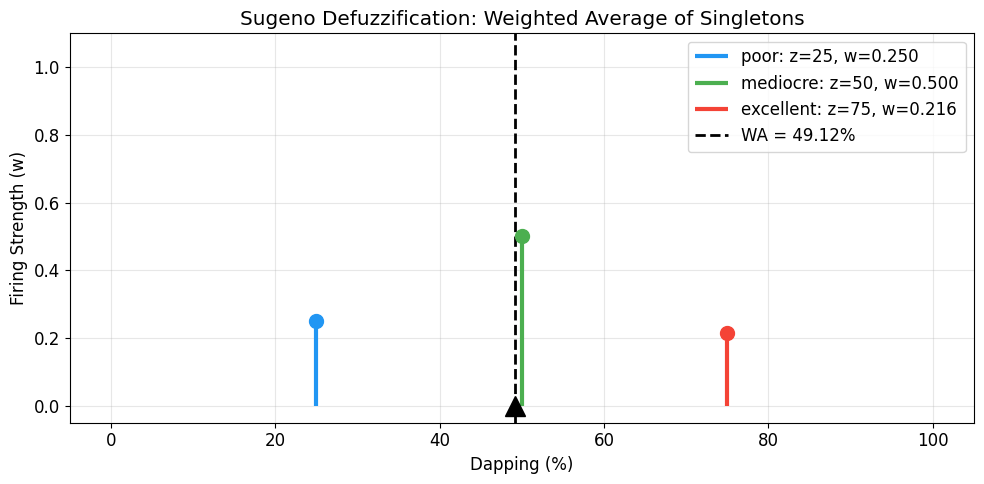

In [11]:
# --- Visualise Sugeno defuzzification ---
# Unlike Mamdani (which aggregates clipped fuzzy sets), Sugeno uses singletons
# weighted by rule firing strengths. The output is their weighted average.
fig, ax = plt.subplots(figsize=(10, 5))
# Singleton positions and firing strengths
singletons = {'Rule 1\npoor': (25, w1), 'Rule 2\nmediocre': (50, w2),
              'Rule 3\nexcellent': (75, w3)}
colors = ['#2196F3', '#4CAF50', '#F44336']
for (label, (z, w)), color in zip(singletons.items(), colors):
    # Vertical line from 0 to firing strength
    ax.vlines(z, 0, w, colors=color, linewidths=3,
              label=f'{label.split(chr(10))[1]}: z={z}, w={w:.3f}')
    ax.plot(z, w, 'o', color=color, markersize=10, zorder=5)
# Weighted average result
wa_sugeno = (w1*25 + w2*50 + w3*75) / (w1 + w2 + w3)
ax.axvline(x=wa_sugeno, color='black', ls='--', lw=2, label=f'WA = {wa_sugeno:.2f}%')
ax.plot(wa_sugeno, 0, 'k^', markersize=14, zorder=5)
ax.set_xlim(-5, 105)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel('Dapping (%)')
ax.set_ylabel('Firing Strength (w)')
ax.set_title('Sugeno Defuzzification: Weighted Average of Singletons')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### B.4: Tsukamoto Inference with pyfuzzylite

In [12]:
# ============================================================
# B.4 — Tsukamoto Inference with pyfuzzylite
# ============================================================
# Tsukamoto output MFs MUST be monotonic (always increasing or always decreasing).
# pyfuzzylite enforces this by only allowing terms with a .tsukamoto() method:
# Ramp, Sigmoid, SShape, ZShape, and Concave.
#
# Below, we approximate the dapping output MFs as monotonic Ramps:
# poor: Ramp(30 → 0) — decreasing (μ=1 at x=0, μ=0 at x=30)
# mediocre: Ramp(20 → 80) — increasing (μ=0 at x=20, μ=1 at x=80)
# excellent: Ramp(50 → 100) — increasing (μ=0 at x=50, μ=1 at x=100)
# ============================================================

print("=" * 65)
print("TSUKAMOTO INFERENCE — pyfuzzylite (dapping example)")
print("=" * 65)

# --- Build the Tsukamoto engine ---
# Input MFs: identical to the Mamdani/Sugeno engines.
# Output MFs: monotonic Ramp approximations.
# Rules: simplified (no hedges) — 4 rules from the old Java Lab 3.
tsukamoto_engine = fl.Engine(
    name="DappingTsukamoto",
    input_variables=[
        fl.InputVariable(name="wind", minimum=0, maximum=12,
                         terms=[t for t in dapping_engine.input_variable("wind").terms]),
        fl.InputVariable(name="temperature", minimum=0, maximum=30,
                         terms=[t for t in dapping_engine.input_variable("temperature").terms]),
    ],
    output_variables=[
        fl.OutputVariable(name="dapping", minimum=0, maximum=100,
                          aggregation=None,
                          defuzzifier=fl.WeightedAverage("Tsukamoto"),
                          terms=[
                              fl.Ramp("poor", 30, 0),       # decreasing
                              fl.Ramp("mediocre", 20, 80),  # increasing
                              fl.Ramp("excellent", 50, 100), # increasing
                          ]),
    ],
    rule_blocks=[
        fl.RuleBlock(name="rules",
                     conjunction=fl.Minimum(), disjunction=fl.Maximum(),
                     implication=fl.Minimum(), activation=fl.General(),
                     rules=[
                         fl.Rule.create(
                             ("if wind is stormy or temperature is low "
                              "then dapping is poor")
                         ),
                         fl.Rule.create(
                             ("if wind is fresh and temperature is average "
                              "then dapping is mediocre")
                         ),
                         fl.Rule.create(
                             ("if wind is stormy or temperature is not low "
                              "then dapping is excellent")
                         ),
                         fl.Rule.create(
                             ("if wind is calm and temperature is not average "
                              "then dapping is poor")
                         ),
                     ]),
    ],
)

# --- Evaluate and trace through the computation ---
wind_val, temp_val = 8, 10
tsukamoto_engine.input_variable("wind").value = float(wind_val)
tsukamoto_engine.input_variable("temperature").value = float(temp_val)
tsukamoto_engine.process()
tsu_result = tsukamoto_engine.output_variable("dapping").value.item()

# Fuzzification (same as Mamdani/Sugeno)
mu_stormy = float(fl.Trapezoid("stormy", 6, 10, 12, 12).membership(wind_val))
mu_fresh = float(fl.Triangle("fresh", 2, 6, 10).membership(wind_val))
mu_calm = float(fl.Trapezoid("calm", 0, 0, 2, 5).membership(wind_val))
mu_low = float(fl.Trapezoid("low", 0, 0, 5, 15).membership(temp_val))
mu_avg = float(fl.Triangle("average", 5, 15, 25).membership(temp_val))

print(f"\nInputs: wind = {wind_val}, temperature = {temp_val}")
print(f"\nFuzzification:")
print(f"  μ_stormy({wind_val}) = {mu_stormy:.3f}  μ_low({temp_val}) = {mu_low:.3f}")
print(f"  μ_fresh({wind_val})  = {mu_fresh:.3f}  μ_average({temp_val}) = {mu_avg:.3f}")
print(f"  μ_calm({wind_val})   = {mu_calm:.3f}  μ_high({temp_val}) = 0.000")

# Rule evaluation (simplified — no hedges)
w1 = max(mu_stormy, mu_low)
w2 = min(mu_fresh, mu_avg)
w3 = max(mu_stormy, 1 - mu_low)
w4 = min(mu_calm, 1 - mu_avg)

print(f"\nRule firing strengths:")
print(f"  R1: stormy OR low     → w1 = max({mu_stormy:.3f}, {mu_low:.3f}) = {w1:.3f}")
print(f"  R2: fresh AND average → w2 = min({mu_fresh:.3f}, {mu_avg:.3f}) = {w2:.3f}")
print(f"  R3: stormy OR NOT low → w3 = max({mu_stormy:.3f}, {1-mu_low:.3f}) = {w3:.3f}")
print(f"  R4: calm AND NOT avg  → w4 = min({mu_calm:.3f}, {1-mu_avg:.3f}) = {w4:.3f}")

# Tsukamoto: invert monotonic output MFs
poor_mf = fl.Ramp("poor", 30, 0)
med_mf = fl.Ramp("mediocre", 20, 80)
exc_mf = fl.Ramp("excellent", 50, 100)

z1 = float(poor_mf.tsukamoto(w1))
z2 = float(med_mf.tsukamoto(w2))
z3 = float(exc_mf.tsukamoto(w3))
z4 = float(poor_mf.tsukamoto(w4))

print(f"\nTsukamoto step — invert monotonic output MFs at each firing strength:")
print(f"  R1 → poor:      μ_poor(z1) = {w1:.3f} ⟹ z1 = {z1:.2f}")
print(f"  R2 → mediocre:  μ_med(z2)  = {w2:.3f} ⟹ z2 = {z2:.2f}")
print(f"  R3 → excellent: μ_exc(z3)  = {w3:.3f} ⟹ z3 = {z3:.2f}")
print(
    (f"  R4 → poor:      μ_poor(z4) = {w4:.3f} ⟹ z4 = {z4:.2f} "
     f"{'(w4≈0, excluded)' if w4 < 0.001 else ''}")
)

# Weighted average (only non-zero weights)
active = [(wi, zi) for wi, zi in [(w1,z1),(w2,z2),(w3,z3),(w4,z4)] if wi > 0.001]
num = sum(w*z for w, z in active)
den = sum(w for w, z in active)
wa = num / den

print(f"\nWeighted average (Tsukamoto defuzzification):")
terms = " + ".join(f"{w:.3f}×{z:.2f}" for w, z in active)
weights = " + ".join(f"{w:.3f}" for w, _ in active)
print(f"  = ({terms}) / ({weights})")
print(f"  = {num:.3f} / {den:.3f}")
print(f"  = {wa:.2f}%")
print(f"\npyfuzzylite result: {tsu_result:.2f}% ✓")

# --- Compare all three methods ---
print(f"\n{'='*65}")
print(f"COMPARISON: Mamdani vs Sugeno vs Tsukamoto (wind={wind_val}, temp={temp_val})")
print(f"{'='*65}")

try:
    print(f"  Mamdani  (COG):       {mamdani_cog:.2f}%  (hedged rules, fuzzy sets)")
    print(f"  Sugeno   (WA):        {sugeno_result:.2f}%  (hedged rules, singletons)")
    print(f"  Tsukamoto (WA):       {tsu_result:.2f}%  (simple rules, monotonic MFs)")
except NameError:
    print("  (Run B.2 and B.3 first to see full comparison)")

print(f"\nNote: The three methods use different output representations and")
print(f"different rule sets (B.2/B.3 use hedged rules; B.4 uses simplified")
print(f"rules without hedges), so numerical differences are expected.")

TSUKAMOTO INFERENCE — pyfuzzylite (dapping example)

Inputs: wind = 8, temperature = 10

Fuzzification:
  μ_stormy(8) = 0.500  μ_low(10) = 0.500
  μ_fresh(8)  = 0.500  μ_average(10) = 0.500
  μ_calm(8)   = 0.000  μ_high(10) = 0.000

Rule firing strengths:
  R1: stormy OR low     → w1 = max(0.500, 0.500) = 0.500
  R2: fresh AND average → w2 = min(0.500, 0.500) = 0.500
  R3: stormy OR NOT low → w3 = max(0.500, 0.500) = 0.500
  R4: calm AND NOT avg  → w4 = min(0.000, 0.500) = 0.000

Tsukamoto step — invert monotonic output MFs at each firing strength:
  R1 → poor:      μ_poor(z1) = 0.500 ⟹ z1 = 15.00
  R2 → mediocre:  μ_med(z2)  = 0.500 ⟹ z2 = 50.00
  R3 → excellent: μ_exc(z3)  = 0.500 ⟹ z3 = 75.00
  R4 → poor:      μ_poor(z4) = 0.000 ⟹ z4 = 30.00 (w4≈0, excluded)

Weighted average (Tsukamoto defuzzification):
  = (0.500×15.00 + 0.500×50.00 + 0.500×75.00) / (0.500 + 0.500 + 0.500)
  = 70.000 / 1.500
  = 46.67%

pyfuzzylite result: 46.67% ✓

COMPARISON: Mamdani vs Sugeno vs Tsukamoto (wind

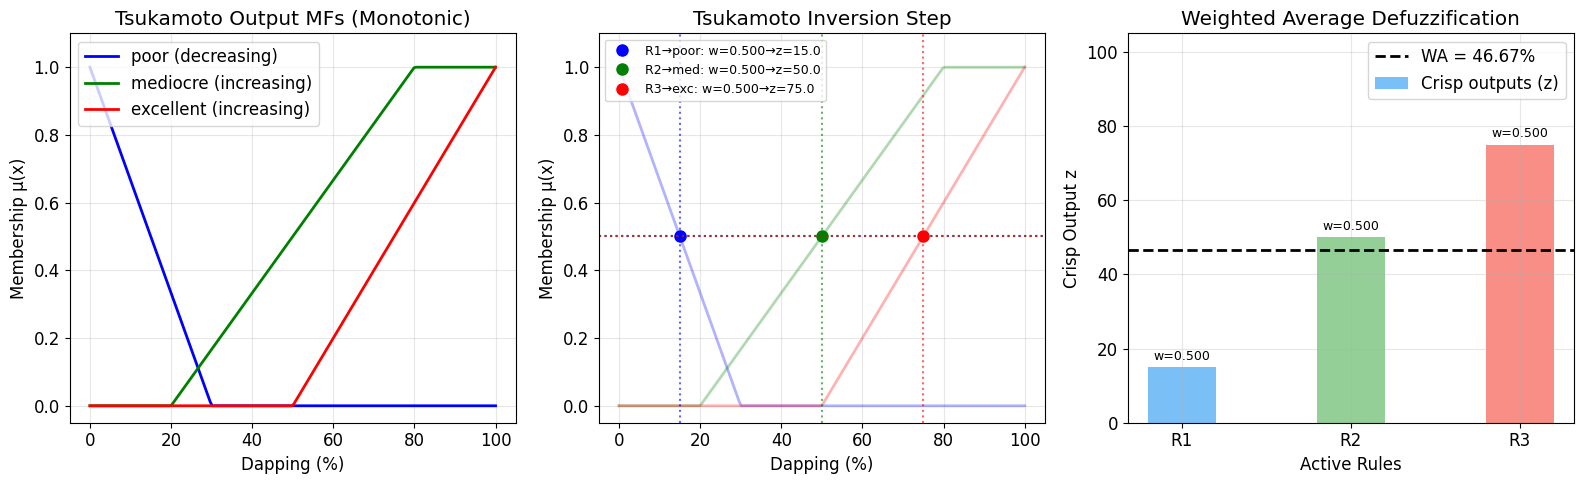

In [13]:
# --- Visualise Tsukamoto defuzzification ---
# Unlike Mamdani (aggregates fuzzy sets) or Sugeno (weighted avg of singletons),
# Tsukamoto inverts monotonic output MFs to find crisp z values at each firing strength.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Left plot: Monotonic output MFs ---
x_dap = np.linspace(0, 100, 200)
poor_vals = [poor_mf.membership(x) for x in x_dap]
med_vals = [med_mf.membership(x) for x in x_dap]
exc_vals = [exc_mf.membership(x) for x in x_dap]

axes[0].plot(x_dap, poor_vals, 'b-', lw=2, label='poor (decreasing)')
axes[0].plot(x_dap, med_vals, 'g-', lw=2, label='mediocre (increasing)')
axes[0].plot(x_dap, exc_vals, 'r-', lw=2, label='excellent (increasing)')
axes[0].set_xlabel('Dapping (%)')
axes[0].set_ylabel('Membership μ(x)')
axes[0].set_title('Tsukamoto Output MFs (Monotonic)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.1)

# --- Middle plot: Inverse mapping (firing strengths → crisp outputs) ---
# Show horizontal lines at firing strengths and vertical lines at inverted z values
axes[1].plot(x_dap, poor_vals, 'b-', lw=2, alpha=0.3)
axes[1].plot(x_dap, med_vals, 'g-', lw=2, alpha=0.3)
axes[1].plot(x_dap, exc_vals, 'r-', lw=2, alpha=0.3)

# Plot inverse mappings for active rules
colors_map = {1: 'blue', 2: 'green', 3: 'red', 4: 'blue'}
labels_map = {1: f'R1→poor: w={w1:.3f}→z={z1:.1f}',
              2: f'R2→med: w={w2:.3f}→z={z2:.1f}',
              3: f'R3→exc: w={w3:.3f}→z={z3:.1f}',
              4: f'R4→poor: w={w4:.3f}→z={z4:.1f}'}
z_vals = {1: z1, 2: z2, 3: z3, 4: z4}
w_vals = {1: w1, 2: w2, 3: w3, 4: w4}

for i in [1, 2, 3, 4]:
    if w_vals[i] > 0.001:
        c = colors_map[i]
        axes[1].axhline(y=w_vals[i], color=c, ls=':', alpha=0.6)
        axes[1].axvline(x=z_vals[i], color=c, ls=':', alpha=0.6)
        axes[1].plot(z_vals[i], w_vals[i], 'o', color=c, markersize=8, label=labels_map[i])

axes[1].set_xlabel('Dapping (%)')
axes[1].set_ylabel('Membership μ(x)')
axes[1].set_title('Tsukamoto Inversion Step')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.05, 1.1)

# --- Right plot: Weighted average of inverted crisp values ---
axes[2].bar(range(len(active)), [z for _, z in active], 
            width=0.4, alpha=0.6, color=['#2196F3', '#4CAF50', '#F44336'][:len(active)],
            label='Crisp outputs (z)')

# Add weights as text above bars
for idx, (w, z) in enumerate(active):
    axes[2].text(idx, z + 2, f'w={w:.3f}', ha='center', fontsize=9)

# Show weighted average result
axes[2].axhline(y=wa, color='black', ls='--', lw=2, label=f'WA = {wa:.2f}%')
axes[2].set_xlabel('Active Rules')
axes[2].set_ylabel('Crisp Output z')
axes[2].set_title('Weighted Average Defuzzification')
rule_labels = ['R1', 'R2', 'R3', 'R4']
axes[2].set_xticks(range(len(active)))
axes[2].set_xticklabels([rule_labels[i] for i in range(len(active))])
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.show()

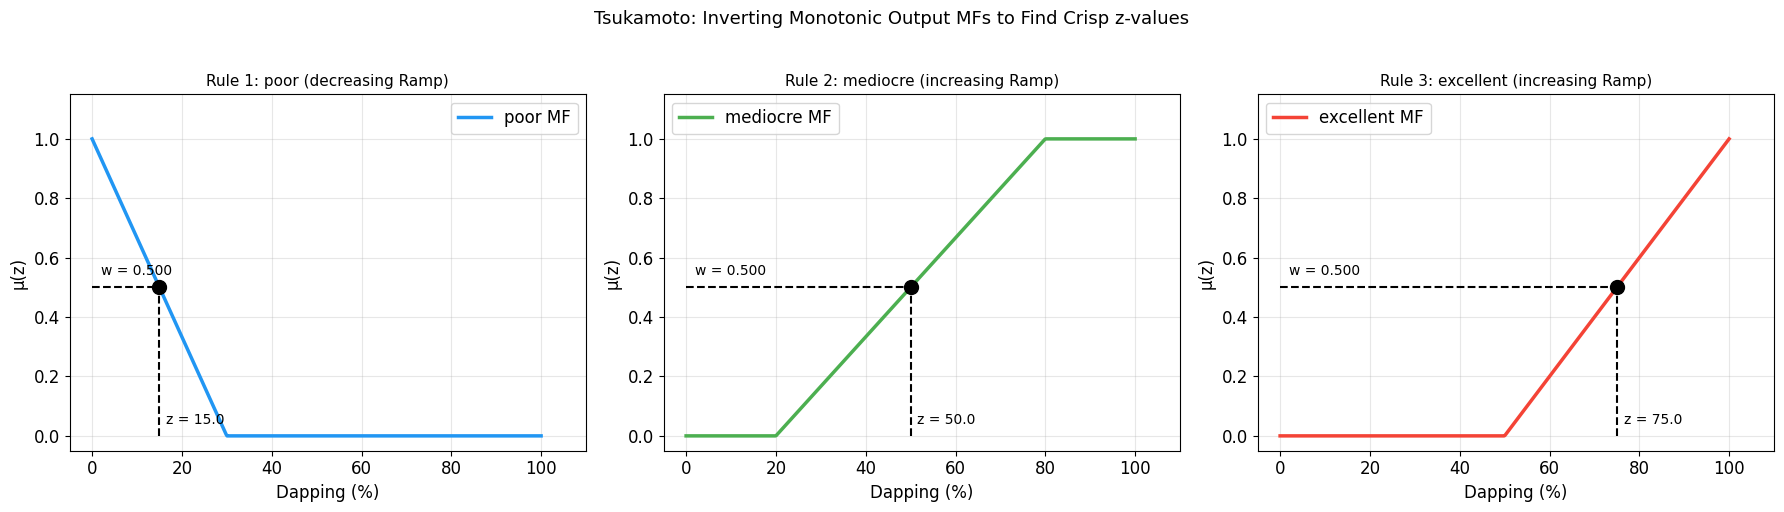

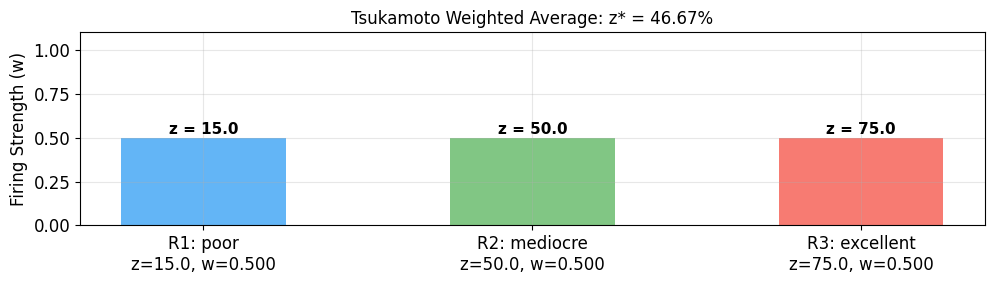

In [14]:
# --- Visualise Tsukamoto defuzzification: MF inversion ---
# Each rule's crisp output z_i is found by inverting the monotonic output MF
# at the rule's firing strength: μ(z_i) = w_i → z_i = μ⁻¹(w_i)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Rule data: (title, Ramp params, firing strength, z-value, color)
rules_data = [
    ('Rule 1: poor (decreasing Ramp)', poor_mf, w1, z1, '#2196F3'),
    ('Rule 2: mediocre (increasing Ramp)', med_mf, w2, z2, '#4CAF50'),
    ('Rule 3: excellent (increasing Ramp)', exc_mf, w3, z3, '#F44336'),
]
for ax, (title, mf, w, z, color) in zip(axes, rules_data):
    # Plot the monotonic MF
    x_out = np.linspace(0, 100, 500)
    y_out = np.array([float(mf.membership(xi)) for xi in x_out])
    ax.plot(x_out, y_out, color=color, lw=2.5, label=f'{mf.name} MF')
    if w > 0.001:  # Only show inversion for non-zero firing strengths
        # Horizontal line at firing strength w
        ax.hlines(w, 0, z, colors='black', linestyles='--', lw=1.5)
        # Vertical line dropping down to z on x-axis
        ax.vlines(z, 0, w, colors='black', linestyles='--', lw=1.5)
        # Mark the intersection point
        ax.plot(z, w, 'ko', markersize=10, zorder=5)
        # Annotate
        ax.annotate(f'w = {w:.3f}', xy=(2, w + 0.04), fontsize=10, color='black')
        ax.annotate(f'z = {z:.1f}', xy=(z + 1.5, 0.04), fontsize=10, color='black')
    ax.set_xlim(-5, 110)
    ax.set_ylim(-0.05, 1.15)
    ax.set_xlabel('Dapping (%)')
    ax.set_ylabel('μ(z)')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper right' if 'decreasing' in title else 'upper left')
plt.suptitle('Tsukamoto: Inverting Monotonic Output MFs to Find Crisp z-values',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
# --- Summary bar showing weighted average ---
fig, ax = plt.subplots(figsize=(10, 3))
weights = [w1, w2, w3]
z_vals = [z1, z2, z3]
labels = [f'R1: poor\nz={z1:.1f}, w={w1:.3f}',
          f'R2: mediocre\nz={z2:.1f}, w={w2:.3f}',
          f'R3: excellent\nz={z3:.1f}, w={w3:.3f}']
bar_colors = ['#2196F3', '#4CAF50', '#F44336']
bars = ax.bar(labels, weights, color=bar_colors, alpha=0.7, width=0.5)
# Show z values as text on bars
for bar, z_val in zip(bars, z_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'z = {z_val:.1f}', ha='center', fontsize=11, fontweight='bold')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylabel('Firing Strength (w)')
ax.set_title(f'Tsukamoto Weighted Average: z* = {wa:.2f}%', fontsize=12)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

### B.5: 3D Surface Plots

Computing Mamdani surface (this may take a moment)...
Computing Sugeno surface...


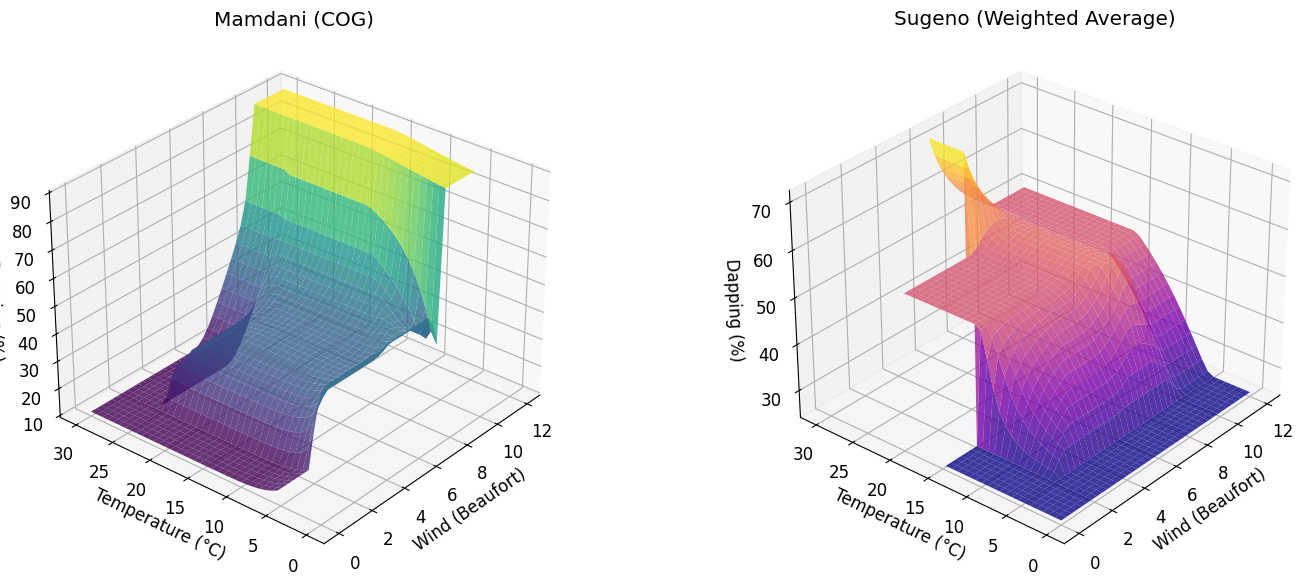

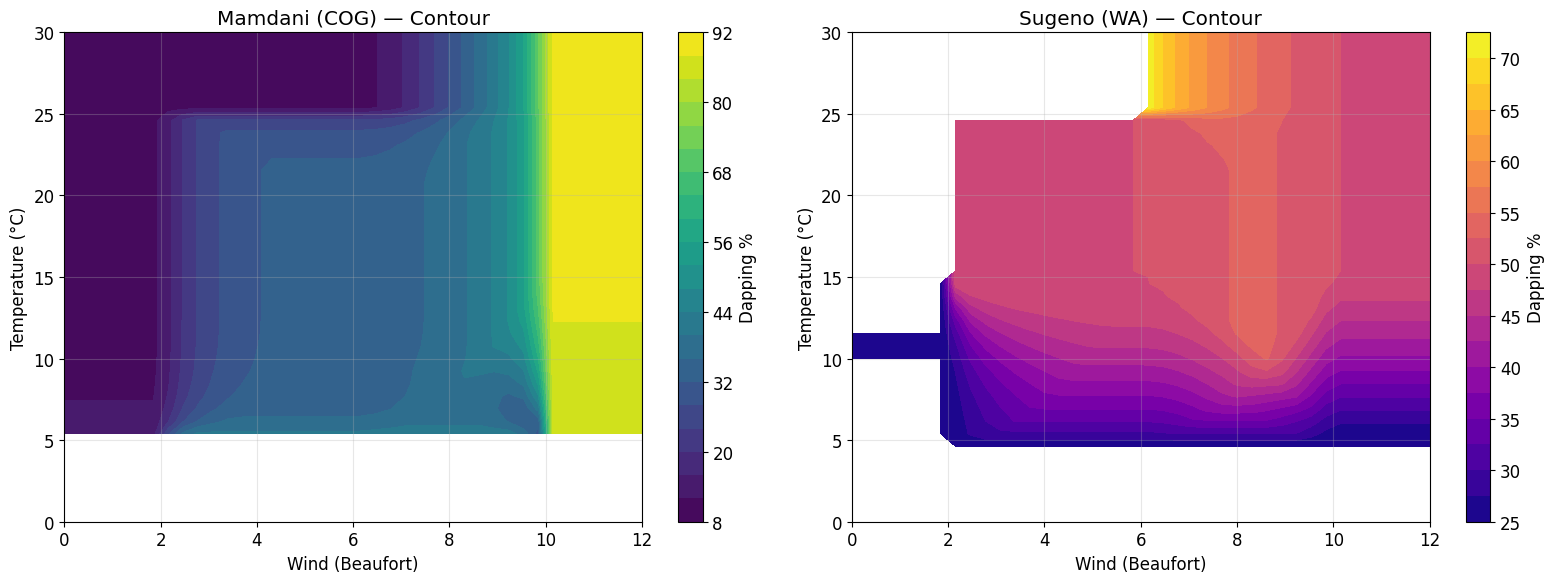

In [15]:
def compute_surface(engine, var1_name, var1_range, var2_name, var2_range, output_name, n=50):
    """Compute a 2D output surface for a fuzzy engine."""
    x1 = np.linspace(var1_range[0], var1_range[1], n)
    x2 = np.linspace(var2_range[0], var2_range[1], n)
    X1, X2 = np.meshgrid(x1, x2)
    Z = np.zeros_like(X1)
    
    for i in range(n):
        for j in range(n):
            engine.input_variable(var1_name).value = float(X1[i, j])
            engine.input_variable(var2_name).value = float(X2[i, j])
            engine.process()
            Z[i, j] = engine.output_variable(output_name).value.item()
    
    return X1, X2, Z

# Compute surfaces for both Mamdani and Sugeno dapping
# Reset Mamdani defuzzifier to COG
dapping_engine.output_variable("dapping").defuzzifier = fl.Centroid(200)

print("Computing Mamdani surface (this may take a moment)...")
X_w, X_t, Z_mamdani = compute_surface(
    dapping_engine, "wind", (0, 12), "temperature", (0, 30), "dapping", n=40
)

print("Computing Sugeno surface...")
X_w2, X_t2, Z_sugeno = compute_surface(
    dapping_sugeno, "wind", (0, 12), "temperature", (0, 30), "dapping", n=40
)

# Plot 3D surfaces side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': '3d'})

ax1.plot_surface(X_w, X_t, Z_mamdani, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Wind (Beaufort)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_zlabel('Dapping (%)')
ax1.set_title('Mamdani (COG)')
ax1.view_init(elev=30, azim=220)

ax2.plot_surface(X_w2, X_t2, Z_sugeno, cmap='plasma', alpha=0.8)
ax2.set_xlabel('Wind (Beaufort)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_zlabel('Dapping (%)')
ax2.set_title('Sugeno (Weighted Average)')
ax2.view_init(elev=30, azim=220)

plt.tight_layout()
plt.show()

# Also plot as contour maps (often easier to read)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

c1 = ax1.contourf(X_w, X_t, Z_mamdani, levels=20, cmap='viridis')
ax1.set_xlabel('Wind (Beaufort)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Mamdani (COG) — Contour')
plt.colorbar(c1, ax=ax1, label='Dapping %')

c2 = ax2.contourf(X_w2, X_t2, Z_sugeno, levels=20, cmap='plasma')
ax2.set_xlabel('Wind (Beaufort)')
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Sugeno (WA) — Contour')
plt.colorbar(c2, ax=ax2, label='Dapping %')

plt.tight_layout()
plt.show()